# 05 — Logistic Regression

**Sprint 7 — Machine Learning Fundamentals for AI/ML Engineers**
**Notebook 5 of 20**

Despite the name, Logistic Regression is a **classification** algorithm, not a regression one — this
notebook exists partly to explain that naming confusion, and partly to introduce the sigmoid function,
decision boundaries, and log loss, which reappear (in more complex forms) throughout the rest of this
sprint.

**Datasets:** a synthetic 2-class blob dataset for visualizing the decision boundary and sigmoid curve
directly, and `sklearn.datasets.load_breast_cancer` (569 real patient samples, 30 features, binary
malignant/benign target, fully bundled — no network download) for a real classification demo, standing
in for MNIST/digits so this notebook has a genuinely different real-world binary classification example
than your Task 2 project.


## 1. Classification and Binary Classification

Recall from Notebook 1: **classification** predicts a discrete category rather than a continuous
number. **Binary classification** is the special case of exactly two possible classes (spam/not-spam,
malignant/benign, default/no-default) — usually encoded as 0 and 1.

## 2. Why is Logistic Regression a classification algorithm despite its name?

Plain Linear Regression (Notebook 4) outputs *any* real number — there's nothing stopping
$\theta_0 + \theta_1 x$ from predicting $-40$ or $300$, which is meaningless for "is this tumor
malignant?" (an answer must be yes/no, or a probability between 0 and 1).

Logistic Regression starts from the *exact same* linear combination of features,
$z = \theta_0 + \theta_1 x_1 + \dots + \theta_n x_n$ — this is the "regression" part, and it's why the
name has stuck historically — but then **squashes** that linear output through the **sigmoid
function** so the result is always a valid probability between 0 and 1, and a threshold turns that
probability into a class label. The "regression" machinery is just the first half of the pipeline; the
final output is a class, which is what makes it a classification algorithm in practice.

## 3. The Sigmoid Function

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

This function takes any real number $z$ (from $-\infty$ to $+\infty$) and maps it to a value strictly
between 0 and 1 — an S-shaped curve. Large positive $z$ → output close to 1. Large negative $z$ →
output close to 0. $z = 0$ → output exactly 0.5.


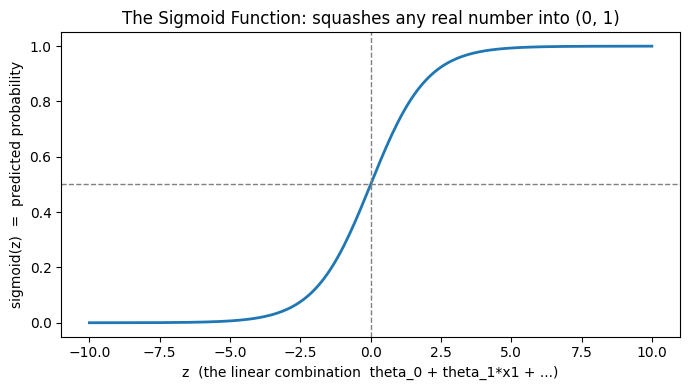

sigmoid( -10) = 0.0000
sigmoid(  -2) = 0.1192
sigmoid(   0) = 0.5000
sigmoid(   2) = 0.8808
sigmoid(  10) = 1.0000


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z, sigmoid(z), linewidth=2)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("z  (the linear combination  theta_0 + theta_1*x1 + ...)")
ax.set_ylabel("sigmoid(z)  =  predicted probability")
ax.set_title("The Sigmoid Function: squashes any real number into (0, 1)")
plt.tight_layout()
plt.savefig("sigmoid.png", dpi=120)
plt.show()

for val in [-10, -2, 0, 2, 10]:
    print(f"sigmoid({val:>4}) = {sigmoid(val):.4f}")


## 4. Probability, Decision Boundary, and Threshold

Logistic Regression's raw output, $\hat{p} = \sigma(z)$, is a **probability** — "the model's estimated
probability that this example belongs to class 1." To get an actual class prediction, apply a
**threshold** (0.5 by default): predict class 1 if $\hat{p} \geq 0.5$, else class 0.

Because $\sigma(z) = 0.5$ exactly when $z = 0$, the threshold of 0.5 corresponds to $z = 0$, i.e. to
$\theta_0 + \theta_1 x_1 + \dots = 0$ — a **linear** equation in the features. This is the **decision
boundary**: the line (2D) or hyperplane (higher dimensions) that separates the region the model
predicts as class 0 from the region it predicts as class 1. It is a straight line/plane because
Logistic Regression is, underneath the sigmoid, a linear model.

The threshold doesn't have to be 0.5 — raising it makes the model more conservative about predicting
class 1 (fewer false positives, more false negatives); lowering it does the opposite. This choice
matters a lot in practice (e.g., a medical screening test might deliberately use a lower threshold to
catch more true positives, accepting more false alarms) — more on this trade-off in Notebook 14.


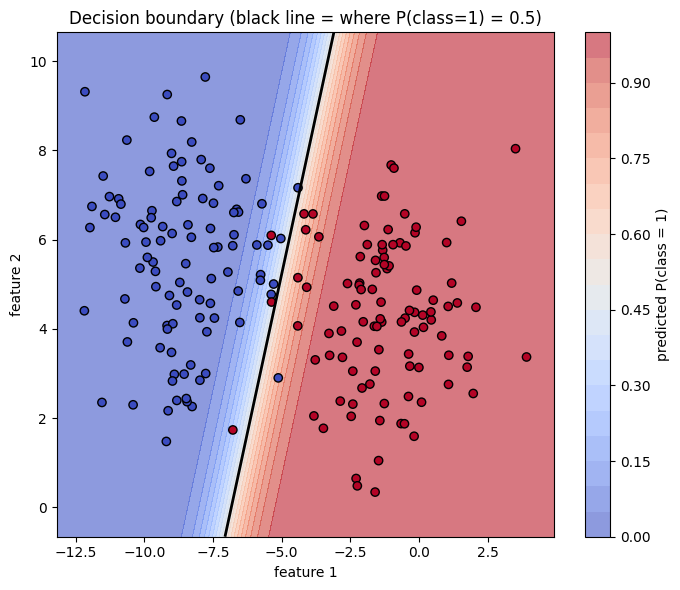

In [2]:
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

Xb, yb = make_blobs(n_samples=200, centers=2, cluster_std=1.8, random_state=7)
clf = LogisticRegression().fit(Xb, yb)

# Build a grid and predict probability of class 1 at every point, to draw the decision boundary
x_min, x_max = Xb[:, 0].min() - 1, Xb[:, 0].max() + 1
y_min, y_max = Xb[:, 1].min() - 1, Xb[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
probs = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 6))
contour = ax.contourf(xx, yy, probs, levels=20, cmap="coolwarm", alpha=0.6)
ax.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)  # the decision boundary itself
ax.scatter(Xb[:, 0], Xb[:, 1], c=yb, cmap="coolwarm", edgecolor="k")
fig.colorbar(contour, ax=ax, label="predicted P(class = 1)")
ax.set_title("Decision boundary (black line = where P(class=1) = 0.5)")
ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
plt.tight_layout()
plt.savefig("decision_boundary.png", dpi=120)
plt.show()


## 5. Log Loss (the cost function for classification)

Mean Squared Error (Notebook 4) is a poor fit for classification: since predictions are probabilities
squashed through a non-linear sigmoid, MSE's cost surface with a sigmoid isn't convex (it can have
multiple local minima, so gradient descent isn't guaranteed to find the best solution). Logistic
Regression instead minimizes **Log Loss** (a.k.a. binary cross-entropy):

$$J(\theta) = -\frac{1}{m}\sum_{i=1}^{m}\Big[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\Big]$$

Intuition: for each example, only ONE of the two terms is active (since $y_i$ is 0 or 1).
- If the true label is 1 ($y_i=1$): the loss is $-\log(\hat{p}_i)$ — this is **small** when
  $\hat{p}_i$ is close to 1 (confident and correct) and **shoots toward infinity** as $\hat{p}_i \to 0$
  (confident and *wrong*).
- If the true label is 0: symmetric, using $-\log(1-\hat{p}_i)$.

So Log Loss **heavily punishes confident wrong predictions** — predicting 0.99 for something that's
actually class 0 costs far more than predicting 0.6, which is exactly the behavior you want out of a
probabilistic classifier's training objective.


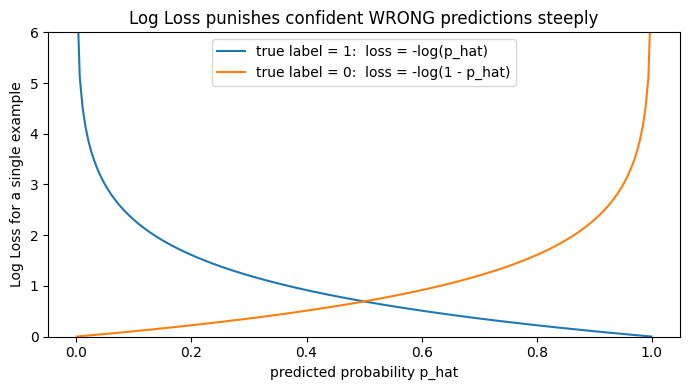

Example: true label = 1
  predicted p_hat = 0.99  ->  Log Loss = 0.010
  predicted p_hat = 0.90  ->  Log Loss = 0.105
  predicted p_hat = 0.60  ->  Log Loss = 0.511
  predicted p_hat = 0.50  ->  Log Loss = 0.693
  predicted p_hat = 0.10  ->  Log Loss = 2.303
  predicted p_hat = 0.01  ->  Log Loss = 4.605


In [3]:
import numpy as np
import matplotlib.pyplot as plt

p_hat = np.linspace(0.001, 0.999, 200)
loss_if_true_label_is_1 = -np.log(p_hat)
loss_if_true_label_is_0 = -np.log(1 - p_hat)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p_hat, loss_if_true_label_is_1, label="true label = 1:  loss = -log(p_hat)")
ax.plot(p_hat, loss_if_true_label_is_0, label="true label = 0:  loss = -log(1 - p_hat)")
ax.set_xlabel("predicted probability p_hat")
ax.set_ylabel("Log Loss for a single example")
ax.set_title("Log Loss punishes confident WRONG predictions steeply")
ax.set_ylim(0, 6)
ax.legend()
plt.tight_layout()
plt.savefig("log_loss.png", dpi=120)
plt.show()

print("Example: true label = 1")
for p in [0.99, 0.9, 0.6, 0.5, 0.1, 0.01]:
    print(f"  predicted p_hat = {p:.2f}  ->  Log Loss = {-np.log(p):.3f}")


## 6. Real classification demo: breast cancer diagnosis


In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix
import pandas as pd

data = load_breast_cancer(as_frame=True)
Xc, yc = data.data, data.target
print("Features:", Xc.shape[1], "| Samples:", Xc.shape[0])
print("Classes:", dict(zip(data.target_names, [0, 1])), "  (0 = malignant, 1 = benign)")
print("Class balance:", yc.value_counts(normalize=True).round(3).to_dict())

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, stratify=yc, random_state=42)

# Pipeline: scale THEN fit (recall Notebook 3's leakage discipline -- fit the scaler on train only)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000)),
])
pipe.fit(Xc_train, yc_train)

yc_pred = pipe.predict(Xc_test)
yc_proba = pipe.predict_proba(Xc_test)[:, 1]

print(f"\nTest accuracy: {accuracy_score(yc_test, yc_pred):.4f}")
print(f"Test Log Loss: {log_loss(yc_test, yc_proba):.4f}")
print("\nConfusion matrix (rows=true, cols=predicted), classes [malignant, benign]:")
print(confusion_matrix(yc_test, yc_pred))

coef_table = pd.Series(pipe.named_steps["clf"].coef_[0], index=Xc.columns).sort_values(key=abs, ascending=False)
print("\nTop 5 most influential (scaled) features:")
print(coef_table.head(5).round(2))


Features: 30 | Samples: 569
Classes: {np.str_('malignant'): 0, np.str_('benign'): 1}   (0 = malignant, 1 = benign)
Class balance: {1: 0.627, 0: 0.373}

Test accuracy: 0.9825
Test Log Loss: 0.0777

Confusion matrix (rows=true, cols=predicted), classes [malignant, benign]:
[[41  1]
 [ 1 71]]

Top 5 most influential (scaled) features:
worst texture          -1.26
radius error           -1.08
worst concave points   -0.95
worst area             -0.95
worst radius           -0.95
dtype: float64


**Reading the confusion matrix and coefficients:** rows are the true class, columns the predicted
class — the diagonal is correct predictions, off-diagonal entries are errors (Notebook 14 covers this
matrix in full depth, including *why* the two off-diagonal cells matter very differently in a medical
context: a false negative here means telling a patient with a malignant tumor that it's benign, which
is a far more serious mistake than the reverse). The largest-magnitude coefficients (on *standardized*
features, so they're comparable to each other) tell you which measurements the model leans on most —
notice this is the same "coefficient = interpretability" property Linear Regression had, just now
describing log-odds of the outcome rather than the outcome directly.


## 7. Multiclass Classification

Logistic Regression as described above handles exactly 2 classes. For more than 2 classes (e.g., the
10 digits in MNIST), there are two standard extensions:

- **One-vs-Rest (OvR)**: train one binary classifier per class ("is it class $k$ or not?"), then predict
  whichever classifier is most confident. $K$ classes → $K$ binary classifiers.
- **Multinomial (Softmax) Logistic Regression**: a direct generalization that computes a probability
  for *every* class simultaneously using the **softmax function** (a multi-class generalization of
  sigmoid), trained with a single combined loss rather than $K$ separate ones. This is scikit-learn's
  default for `LogisticRegression` when there are more than 2 classes.

Both are available via `LogisticRegression(multi_class=...)` — scikit-learn picks a sensible default
automatically based on the data.


In [5]:
from sklearn.datasets import load_digits
from sklearn.model_selection import cross_val_score, StratifiedKFold

digits = load_digits()
Xd, yd = digits.data, digits.target
print("Digits classes:", sorted(set(yd)), "-> more than 2 classes, so this is inherently multiclass")

multi_clf = LogisticRegression(max_iter=5000)
scores = cross_val_score(multi_clf, Xd, yd, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring="accuracy")
print(f"5-fold CV accuracy on 10-class digit classification: {scores.mean():.4f} (+/- {scores.std():.4f})")


Digits classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)] -> more than 2 classes, so this is inherently multiclass


5-fold CV accuracy on 10-class digit classification: 0.9666 (+/- 0.0046)


## 8. Summary — Key Takeaways

- Logistic Regression is a *classification* algorithm: it takes the same linear combination of features
  as Linear Regression, squashes it through the sigmoid function into a probability, then applies a
  threshold (0.5 by default) to get a class label.
- The decision boundary is linear because the sigmoid's 0.5 crossing point corresponds to a linear
  equation in the raw features ($z = 0$).
- Log Loss (not MSE) is the right cost function for probabilistic classification — it's convex for this
  model and heavily punishes confident, wrong predictions.
- Coefficients remain directly interpretable (in terms of log-odds), same as Linear Regression.
- More than 2 classes is handled via One-vs-Rest or Softmax/multinomial extensions.


## 9. Try It Yourself (no solutions given)

1. In Section 4, change the threshold from 0.5 to 0.3 and to 0.7 (recompute predicted classes from
   `clf.predict_proba` manually using `>= threshold` instead of calling `.predict()`). How does the
   decision boundary move, and which class grows/shrinks?
2. On the breast cancer dataset (Section 6), recompute predictions using a threshold of 0.3 instead of
   0.5 (again via `predict_proba`), and print the new confusion matrix. Given that a false negative
   (predicting benign when the tumor is actually malignant) is the more dangerous error here, does
   lowering the threshold help or hurt in the direction that matters?
3. Remove the `StandardScaler` step from the Section 6 pipeline and refit directly on unscaled features.
   Does accuracy change much? Does the *coefficient table's* usefulness for interpretation change, even
   if accuracy barely moves? (Hint: think about what "largest coefficient" means when features are on
   wildly different scales, e.g. `mean area` vs `mean smoothness`.)
4. Explain, in your own words, why Log Loss going to infinity for a confident-and-wrong prediction is a
   *desirable* property for a training objective, rather than a flaw.
